# 05 - Model Explanation

## 1. Load Data and Tuned XGBoost Model

We load the cleaned Telco dataset, recreate the train/test split and load the tuned XGBoost model

In [1]:
import pandas as pd
import numpy as np
import shap
import joblib

from sklearn.model_selection import train_test_split

shap.initjs()

df = pd.read_csv("../data/cleaned_telco.csv")

X = df.drop("Churn", axis=1)
y = (df["Churn"] == "Yes").astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

best_model = joblib.load("../models/best_xgb_model.pkl")
print("Test shape:", X_test.shape)

Test shape: (1409, 40)


## 2. Create SHAP TreeExplainer and Compute SHAP Values

We use `TreeExplainer` for our XGBoost model.  
SHAP values tell us how much each feature pushes the prediction towards **churn** or **non-churn**.

- Positive SHAP value → pushes prediction towards churn.
- Negative SHAP value → pushes prediction towards non-churn.

In [2]:
explainer = shap.TreeExplainer(best_model)

shap_values = explainer(X_test)

print("SHAP values shape:", shap_values.shape)

SHAP values shape: (1409, 40)


## 3. Global Feature Importance – SHAP Summary Plot

This plot shows:
- Which features are most important globally.
- How feature values (high/low) affect churn risk.
- Red points: higher feature values.
- Blue points: lower feature values.

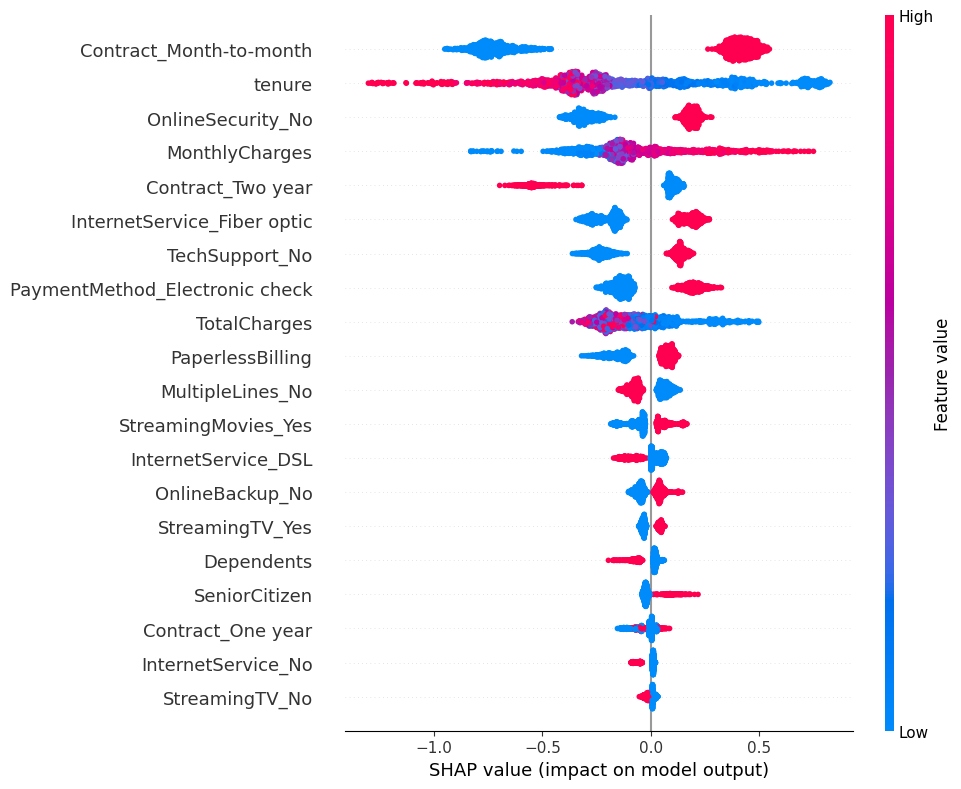

In [3]:
shap.summary_plot(shap_values, X_test, plot_size=(10,8))

## 4. Global Feature Importance - Bar Plot

The bar plot gives a simpler view of **average absolute SHAP values**,  
i.e., the overall impact of each feature on model predictions.

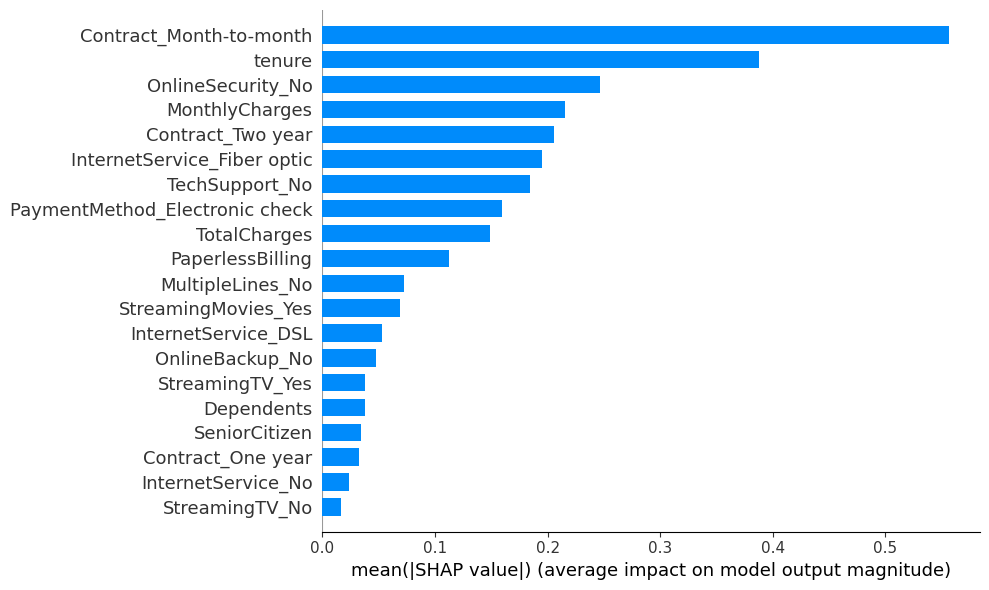

In [4]:
shap.summary_plot(shap_values, X_test, plot_type="bar", plot_size=(10,6))

## 5. SHAP Dependence Plot

We examine how individual features influence churn probability by visualizing:
* X-axis : feature value (e.g., months of tenure)
* Y-axis : SHAP value (impact on model output)
* Color : interaction with another feature

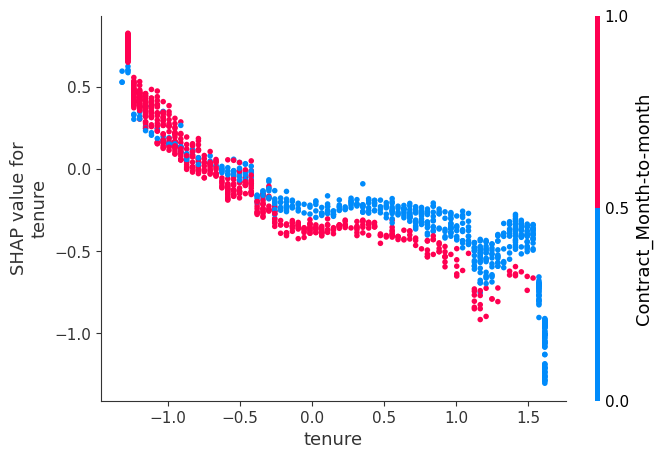

In [5]:
shap.dependence_plot("tenure", shap_values.values, X_test)

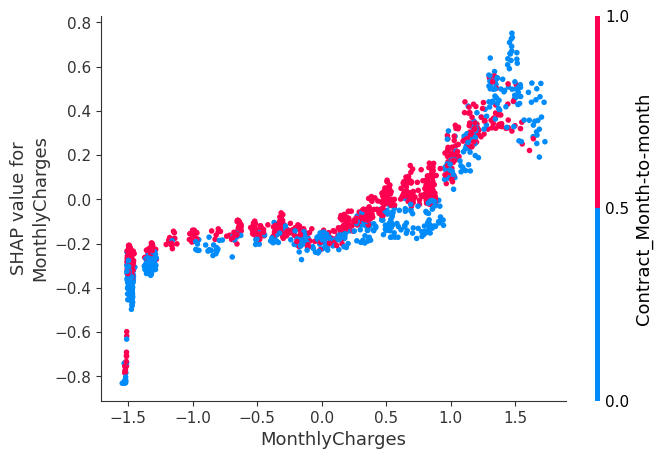

In [6]:
shap.dependence_plot("MonthlyCharges", shap_values.values, X_test)

## 6. Local Explanation - Waterfall Plot for a Single Customer

We now explain one specific customer's prediction in detail

The waterfall plot shows:

* Red bars: features that push the prediction towards churn
* Blue bars: features that push the prediction towards non-churn

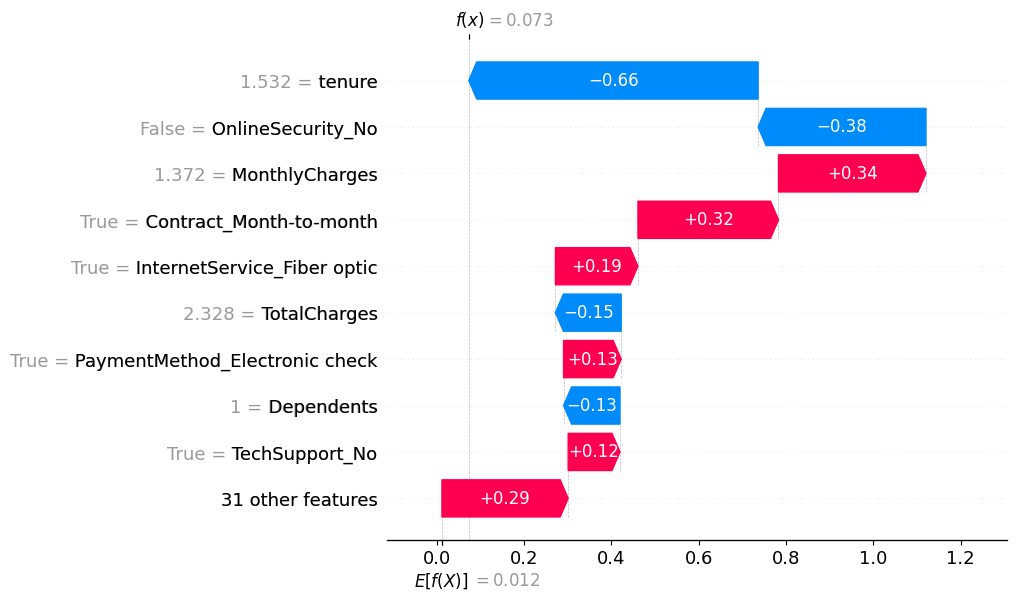

In [7]:
index = 10 # customer index
shap.plots.waterfall(shap_values[index])

For this specific customer, the main factors increasing the churn prediction are:
* Month-to-month contract (+0.39)
* Fiber optic internet service (+0.26)
* High average monthly charges (+0.17)

On the other hand, the following features reduce the churn risk:
* Long tenure (–0.53)
* Having OnlineSecurity (the absence flag = False) (–0.30)
* These contributions reveal why the model predicts a higher churn probability for this customer and provide a clear, step-by-step understanding of the decision.

Churned Customer:


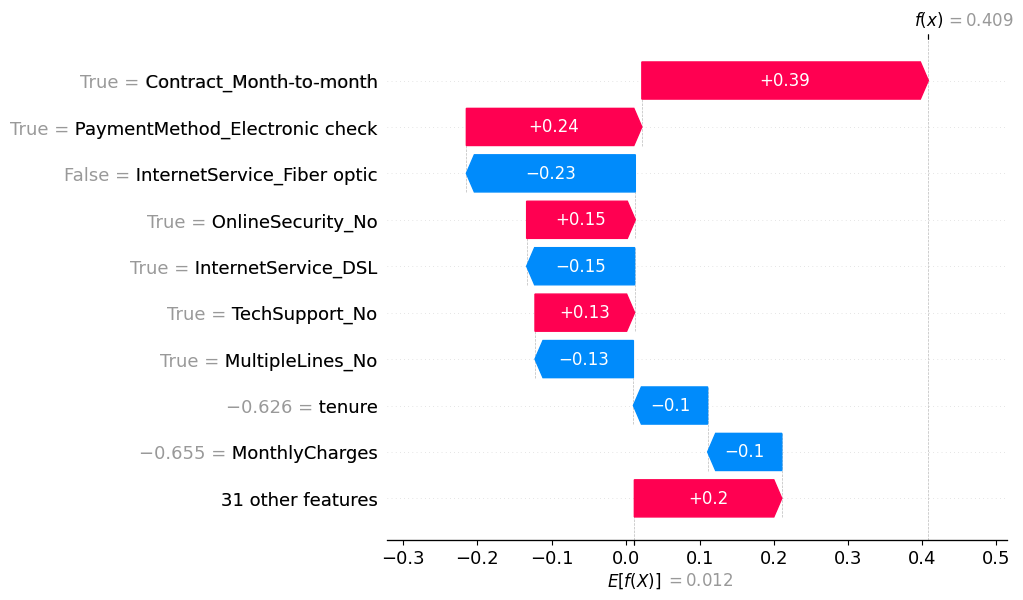

Non-Churned Customer:


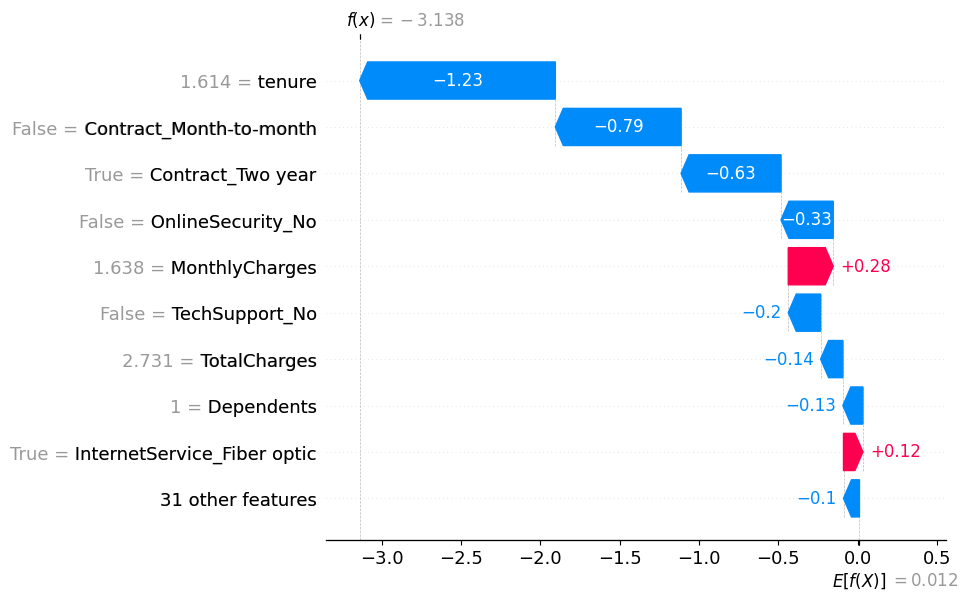

In [8]:
# Identify an example churned customer (label = 1)
churn_index = y_test[y_test == 1].index[0]
churn_index_position = X_test.index.get_loc(churn_index)

# Identify an example non-churned customer (label = 0)
no_churn_index = y_test[y_test == 0].index[0]
no_churn_index_position = X_test.index.get_loc(no_churn_index)

print("Churned Customer:")
shap.plots.waterfall(shap_values[churn_index_position])

print("Non-Churned Customer:")
shap.plots.waterfall(shap_values[no_churn_index_position])

## 7. SHAP Insights – What Drives Churn?

Using SHAP, we can clearly understand which features push the model towards predicting churn or non-churn.  
Below is a summary of the most important global drivers:

### Key Factors Increasing Churn Risk
- **Contract type:** Month-to-month contracts strongly increase churn risk.
- **Tenure:** Customers with short tenure are much more likely to churn.
- **OnlineSecurity & TechSupport:** Lack of these services pushes customers towards churn.
- **InternetService (Fiber optic):** Fiber users show higher churn risk.
- **MonthlyCharges:** Higher monthly charges are associated with higher churn probability.

### Key Factors Reducing Churn Risk
- **Long tenure:** Long-standing customers are much less likely to churn.
- **Having OnlineSecurity / TechSupport:** These services reduce churn probability.
- **Electronic payment methods & stable billing patterns:** These behaviors are associated with lower churn.

## 8. Model Explainability Summary

### Model Performance
- ROC AUC: **0.84**
- Recall: **0.81**
- The model handles class imbalance well and successfully identifies churners.

### Explainability Strength
- SHAP makes the model fully transparent.
- We can see *why* the model predicts churn for each customer.
- Provides both **global** (overall feature importance) and **local** (customer-level) explanations.
- Helps translate the model predictions into clear, actionable business insights.

